# Exploratory Text Analysis of 18th Century Runaway Slave Advertisements

The intersection of Atlantic slavery studies and computational linguistics offers a profound opportunity to interrogate the historical record of the eighteenth and nineteenth centuries with unprecedented depth and breadth. Runaway slave advertisements—documents originally created to commodify, police, and recapture human beings—paradoxically serve as one of the most granular and extensive archives of the enslaved population’s individuality, agency, and resistance. These notices, placed by enslavers in newspapers such as The Boston Newsletter, The American Weekly Mercury, and The New-York Gazette, contain specific data points regarding physical appearance, linguistic abilities, trades, family connections, and strategies of escape. However, the sheer volume of these advertisements, which number in the hundreds of thousands across the Atlantic world—projects like "Freedom on the Move" estimate over 100,000 such ads exist for North America alone—necessitates a methodological shift from traditional close reading to "distant reading" and computational analysis.

Crucially, the application of digital tools to this archive requires an ethical framework that refuses to replicate the dehumanization inherent in the original documents. While the enslaver wrote the ad to reclaim property, the digital humanist mines the ad to recover the person. When an advertisement describes a fugitive as having a "down look" or being "artful," the computational analysis must interpret these not as objective traits, but as markers of the power dynamic between the watcher and the watched—evidence of a psychological war occurring on the plantation and in the household.


This report outlines the process for the exploratory text analysis of the dataset Pretends to Be Free, a collection of runaway slave advertisements from colonial and revolutionary New York and New Jersey. The dataset provided, encompassing records from 1716 to 1766, offers a longitudinal view of slavery in the these states. It captures the shift from a society with slaves to a slave society, the complexities of Indigenous and African enslavement, and the cosmopolitan, multi-lingual nature of the unfree population in New York and New Jersey.


# Loading the Corpus and Initial Inspection

In [2]:
#load the necessary libraries
import pandas as pd
import time
import re
import nltk
from nltk.corpus import stopwords

In [3]:
# Load the dataset
df = pd.read_csv('/Users/mirayozmutlu/Documents/GitHub/DH-Project---Runaway-Slave-Advertisements/_Pretends To Be Free_ - Runaway Slave Ads - Sheet1 (1).csv')

# Initial inspection of the dataframe structure
print(df.head())
print(df.info())

                               Newspaper Name  Issue No       Date   \
0                       The Boston Newsletter       641   7/23/1716   
1  The American Weekly Mercury (Philadelphia)       153  11/15/1722   
2  The American Weekly Mercury (Philadelphia)       190    8/1/1723   
3  The American Weekly Mercury (Philadelphia)       239    7/9/1724   
4  The American Weekly Mercury (Philadelphia)       249   9/17/1724   

                                             Content  
0  This is to give notice that on the 16th of Jul...  
1  Runaway from William Yard of Trenton in West-J...  
2  Runaway about the 15th of June last, from Gabr...  
3  Second River, June 30, 1762. Run away from his...  
4  Runaway from the Plantation of Cornelius Van H...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Newspaper Name  300 non-null    object
 1   Is

The dataset contains four primary columns: Newspaper Name, Issue No, Date (yyyy/mm/dd), and Content. The Content column is the unstructured text field that serves as the primary source for NLP analysis.

Upon loading, a careful review of the first few rows is essential to understand the nature of the data. As seen in snippet 1, the content varies significantly. Row 1 details the escape of "Nim," an "Indian Man," highlighting the often-overlooked phenomenon of Indigenous enslavement in the Northeast. Row 2 describes "Fransh Manuel," a "Negroe Man" who "pretended formerly to be a Freeman," pointing to the legal and social ambiguities of status in the period. These entries confirm that the dataset is not monolithic; it contains diverse categories of unfree labor and resistance strategies.

#  Temporal Formatting and Normalization

By isolating the year and month, one can generate visualizations that track the seasonality of escapes.

In [9]:
# find a date-like column (case-insensitive); set `date_col` manually if detection fails
date_col = next((c for c in df.columns if 'date' in c.lower()), None)
if date_col is None:
    raise ValueError("No column with 'date' in its name found. Set `date_col` to the correct column name.")

# convert only that column to datetime (coerce invalid parsing to NaT)
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

# create Year and Month columns
df['Year'] = df[date_col].dt.year
df['Month'] = df[date_col].dt.month

# quick check
print(df[[date_col, 'Year', 'Month']].head())
print(f"Parsed {df[date_col].notna().sum()} valid dates out of {len(df)} rows.")

       Date   Year  Month
0 1716-07-23  1716      7
1 1722-11-15  1722     11
2 1723-08-01  1723      8
3 1724-07-09  1724      7
4 1724-09-17  1724      9
Parsed 300 valid dates out of 300 rows.


# Document Classification: Distinguishing Runaway from Capture Notices

While most are "Runaway" notices placed by enslavers seeking the return of a fugitive, others are "Taken Up" or "Jailer's" notices.
- **Runaway Notices**: These are characterized by the language of ownership and pursuit ("Runaway from his Master..."). They describe the person from memory, focusing on identifying marks, habits, and likely destinations.
- **Capture/Jailer Notices**: These are written by sheriffs or jailers describing a person in custody ("Notice is hereby given, That there is come to the House of..."). As seen in Row 6 of the dataset 1, these ads describe the person from observation, often noting physical traits like filed teeth or a refusal to name a master ("he will not tell his Masters Name").

This distinction is vital for analysis. Runaway ads reflect the enslaver's perception of the fugitive, while capture ads reflect the state's interaction with the fugitive.

In [4]:
def classify_ad_type(text):
    # handle missing or non-string values
    if pd.isna(text):
        return 'Other'
    text = str(text).lower()
    # use word-boundary regex to match common variants
    if re.search(r'\b(run\s?away|ran\s?away|runaway)\b', text):
        return 'Runaway'
    if re.search(r'\b(taken up|custody|gaol|jail)\b', text):
        return 'Capture'
    return 'Other'

# usage: add a new column rather than overwriting the DataFrame
df['AdType'] = df['Content'].apply(classify_ad_type)

# Preprocessing: The Challenge of 18th-Century English

## Orthographic Normalization and Standardization

The advantage of LLMs in this process was identifying domain-specific inconsistencies allowing me to manually enter rules for normalization.

In [5]:
def normalize_text(text):
    if not isinstance(text, str):
        return ""

    # Lowercase for uniformity
    text = text.lower()

    # Standardize common archaic terms found in runaway ads
    text = re.sub(r'\bnegroe\b', 'negro', text)
    text = re.sub(r'\bcloathes\b', 'clothes', text)
    text = re.sub(r'\bcloaths\b', 'clothes', text)
    text = re.sub(r'\bgaol\b', 'jail', text)
    text = re.sub(r'\bgoal\b', 'jail', text)
    text = re.sub(r'\bwest-coat\b', 'waistcoat', text)
    text = re.sub(r'\bwastecoat\b', 'waistcoat', text)
    text = re.sub(r'\bwestcoat\b', 'waistcoat', text)
    text = re.sub(r'\bbritches\b', 'breeches', text)
    text = re.sub(r'\bozenbrigs\b', 'osnaburg', text) # A common coarse fabric
    text = re.sub(r'\bosenbrigs\b', 'osnaburg', text)
    text = re.sub(r'\bozenbrig\b', 'osnaburg', text)

    # Remove punctuation for bag-of-words analysis
    text = re.sub(r'[^\w\s]', '', text)

    return text

df['cleaned_content'] = df['Content'].apply(normalize_text)

This normalization is critical. Without it, an analysis of clothing, a key identifier in these ads, would split the data between "breeches" and "britches,", for example, diluting the insight that clothing was a primary mode of surveillance and identification.

## Tokenization and Domain-Specific Stop Word Removal

Once normalized, the text must be tokenized (split into individual words). Standard stop word lists (words like "the", "and", "is") provided by libraries like NLTK are insufficient for this corpus because the "boilerplate" language of runaway ads constitutes a form of domain-specific stop words.
Terms such as "runaway", "whereas", "subscriber", "master", "reward", "shillings", and "pounds" appear in nearly every document. While historically significant as markers of the legal and economic framework of slavery, they create noise that obscures the unique descriptors of the enslaved individuals when attempting to cluster texts or identify unique characteristics. A custom stop word list must be curated to filter out this administrative debris.


In [7]:
# map resource names to nltk.data paths
_RESOURCE_PATHS = {
    'punkt': 'tokenizers/punkt',
    'stopwords': 'corpora/stopwords',
}

def ensure_nltk_resource(name, max_retries=3):
    path = _RESOURCE_PATHS.get(name)
    if not path:
        return False
    try:
        nltk.data.find(path)
        return True
    except LookupError:
        delay = 1.0
        for attempt in range(max_retries):
            try:
                nltk.download(name, quiet=True)
                nltk.data.find(path)
                return True
            except Exception:
                if attempt < max_retries - 1:
                    time.sleep(delay)
                    delay *= 2
                else:
                    return False

# ensure resources (won't re-download if already present)
punkt_ok = ensure_nltk_resource('punkt')
stopwords_ok = ensure_nltk_resource('stopwords')

# prepare stop words (fallback to empty set if not available)
try:
    stop_words = set(stopwords.words('english')) if stopwords_ok else set()
except Exception:
    stop_words = set()

# add domain-specific boilerplate words
boilerplate = {
    'runaway', 'run', 'away', 'master', 'subscriber', 'whereas',
    'named', 'reward', 'shillings', 'pounds', 'paid', 'charges',
    'reasonable', 'notice', 'give', 'secure', 'bring', 'delivered',
    'whoever', 'takes', 'person', 'negro', 'man', 'fellow', 'woman', 'wench',
    'said', 'return', 'jail', 'gaol', 'shall', 'may', 'went', 'says', 'years'
}
stop_words.update(boilerplate)

# robust tokenizer: use nltk if punkt is available, otherwise a regex fallback
def tokenize_text(text):
    if not isinstance(text, str):
        return []
    if punkt_ok:
        try:
            return nltk.word_tokenize(text)
        except Exception:
            pass
    # fallback: simple word tokenization (keeps only word characters)
    return re.findall(r'\b\w+\b', text.lower())

def remove_stopwords(text):
    tokens = tokenize_text(text)
    return [w for w in tokens if w.lower() not in stop_words]

# Example application (assuming `df` and `cleaned_content` already exist):
df['tokens'] = df['cleaned_content'].apply(remove_stopwords)

## Descriptive Analytics

## Temporal Analysis

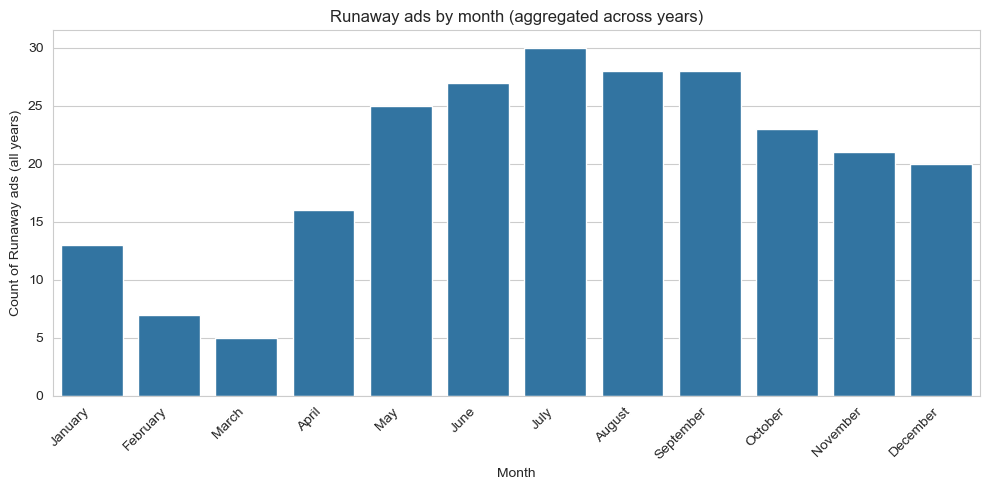

In [10]:
# python
import calendar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ensure `AdType` exists
if 'AdType' not in df.columns:
    raise KeyError("DataFrame missing `AdType`. Run the classifier first.")

# ensure `Month` exists (fallback to `date_col` if available)
if 'Month' not in df.columns:
    if 'date_col' in globals() and date_col in df.columns:
        df['Month'] = pd.to_datetime(df[date_col], errors='coerce').dt.month
    else:
        raise KeyError("Missing `Month` column and no `date_col` available.")

# compute counts for runaway ads aggregated across years (1..12)
mask = df['AdType'] == 'Runaway'
monthly_counts = (
    df.loc[mask]
      .dropna(subset=['Month'])
      .astype({'Month': int})
      .groupby('Month')
      .size()
      .reindex(range(1, 13), fill_value=0)
)

# map month numbers to names and plot
month_names = [calendar.month_name[m] for m in range(1, 13)]

sns.set_style('whitegrid')
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=month_names, y=monthly_counts.values, color='C0', order=month_names)
ax.set_xlabel('Month')
ax.set_ylabel('Count of Runaway ads (all years)')
ax.set_title('Runaway ads by month (aggregated across years)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Visualization shows higher counts of runaways during summer and early fall months. These months were probably preferred due to suitable weather conditions. Early fall months are consistent with historical scholarship which suggests that flights often correlated with labor cycles (harvest times).

### Frequency Analysis

/var/folders/vv/gfx_q3l53478yh5pl7vm75000000gn/T/ipykernel_2156/981037179.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=common_words, palette='viridis')


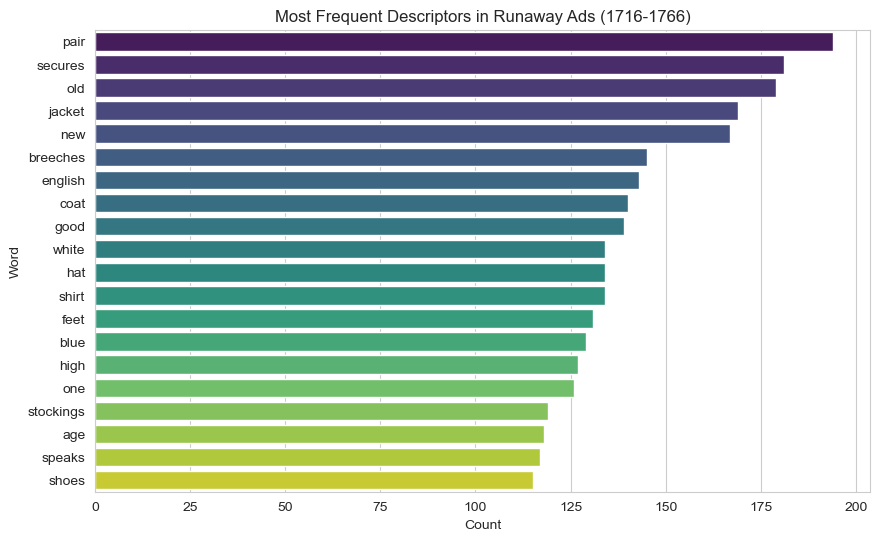

In [12]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten list of tokens
all_words = [word for tokens in df['tokens'] for word in tokens]
word_freq = Counter(all_words)

# Plot top 20 words
common_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Word', data=common_words, palette='viridis')
plt.title('Most Frequent Descriptors in Runaway Ads (1716-1766)')
plt.show()

Analyzing the most frequent words reveals the priorities of the enslaver. In the Pretends to Be Free dataset, we see high frequencies of words related to clothing (e.g., "jacket", "coat", "shirt", "breeches"), physical markers ("scar", "pox", "brand"), and skills ("speaks", "good").

## N-Gram Analysis: Collocations of Captivity and Resistance

Single words often lack context. N-grams (bi-grams and tri-grams) capture the phrasing patterns that constitute the genre of the runaway ad.

"Speaks good English": This bi-gram appears repeatedly. It signals acculturation and the length of time in the colonies. Conversely, "new negro" or "country born" signals arrival status.

"Pock broken" / "Small pox": Indicates the prevalence of disease and its use as a permanent biometric identifier. The scars of smallpox were as identifying as a brand.

"Down look" / "Sly look": These are subjective psychological assessments by the enslaver. They interpret the enslaved person’s demeanor as sullen or guilty rather than resistant or traumatized. Identifying these phrases helps quantify the "medicalization" of the enslaved body—how it was cataloged as a damaged or marked commodity.



[(('inches', 'high'), 93), (('good', 'english'), 71), (('5', 'feet'), 71), (('new', 'york'), 54), (('speaks', 'good'), 53), (('felt', 'hat'), 51), (('masters', 'vessels'), 50), (('leather', 'breeches'), 46), (('well', 'set'), 45), (('secures', 'forty'), 32)]


/var/folders/vv/gfx_q3l53478yh5pl7vm75000000gn/T/ipykernel_2156/452469890.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count', y='Bigram', data=plot_df, palette='plasma')


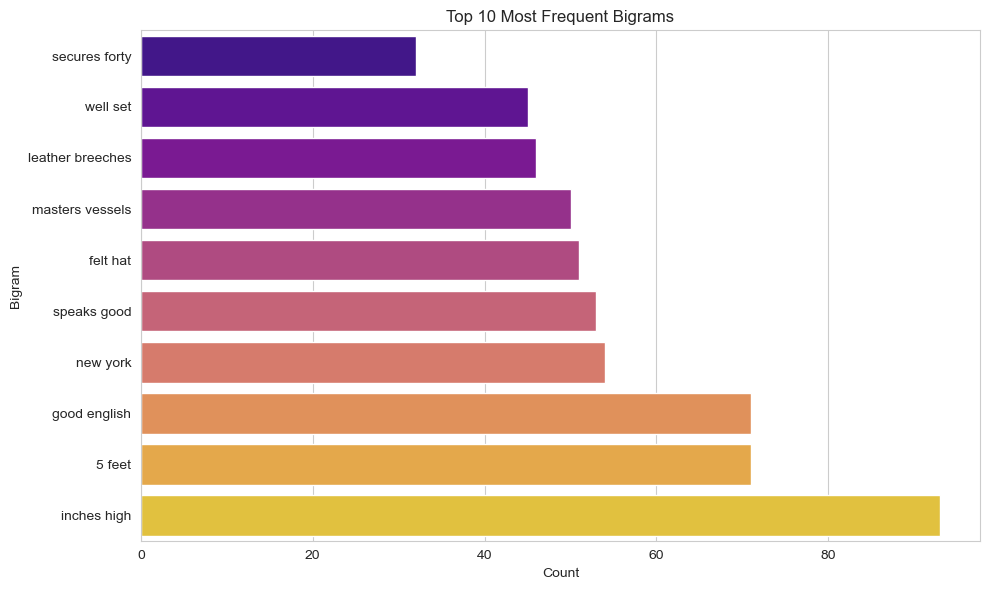

In [13]:
from nltk.util import ngrams

# Generate Bi-grams
all_bigrams = ngrams(all_words, 2)
bigram_freq = Counter(all_bigrams)

# Display most common bi-grams
print(bigram_freq.most_common(10))

# build bigram counts safely (skip NaN / non-iterable token rows)
bigram_counter = Counter()
for tokens in df['tokens'].dropna():
    if not isinstance(tokens, (list, tuple)):
        continue
    cleaned = [str(t).lower() for t in tokens if str(t).strip()]
    if len(cleaned) < 2:
        continue
    bigram_counter.update(zip(cleaned, cleaned[1:]))

# get top 10 bigrams
top_n = 10
most_common = bigram_counter.most_common(top_n)
if not most_common:
    raise ValueError("No bigrams found in `df['tokens']`.")

# prepare DataFrame with readable bigram labels
plot_df = pd.DataFrame(
    [{'Bigram': ' '.join(bigram), 'Count': count} for bigram, count in most_common]
)
# ensure descending order
plot_df = plot_df.sort_values('Count', ascending=True)  # ascending for horizontal bars

# plot horizontal bar chart
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Count', y='Bigram', data=plot_df, palette='plasma')
ax.set_title('Top 10 Most Frequent Bigrams')
ax.set_xlabel('Count')
ax.set_ylabel('Bigram')
plt.tight_layout()
plt.show()


/var/folders/vv/gfx_q3l53478yh5pl7vm75000000gn/T/ipykernel_2156/140134721.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count', y='Trigram', data=plot_df, palette='magma')


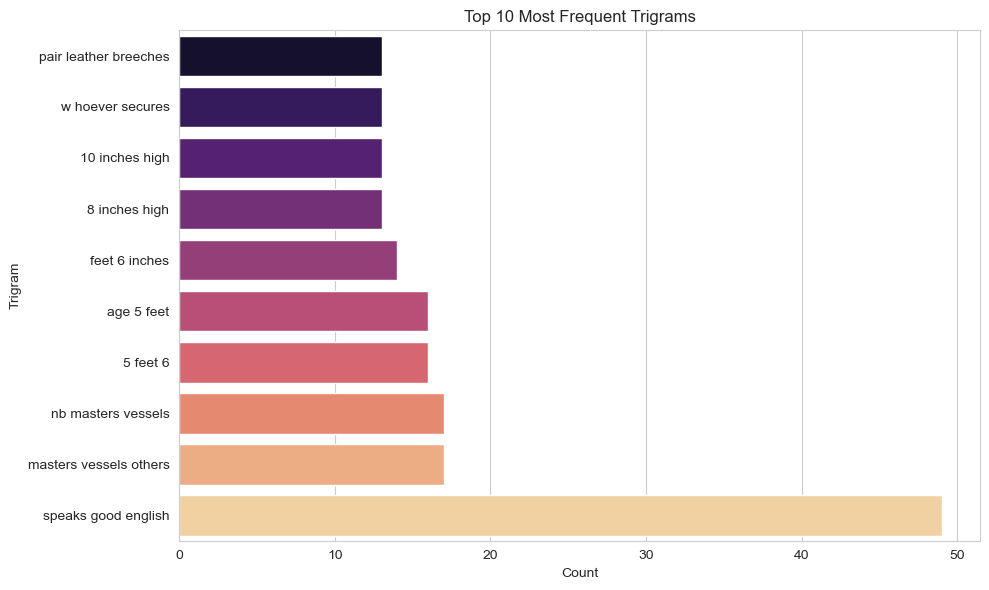

In [14]:
# Generate Tri-grams
# Build trigram counts safely
trigram_counter = Counter()
for tokens in df['tokens'].dropna():
    if not isinstance(tokens, (list, tuple)):
        continue
    cleaned = [str(t).lower() for t in tokens if str(t).strip()]
    if len(cleaned) < 3:
        continue
    trigrams = zip(cleaned, cleaned[1:], cleaned[2:])
    trigram_counter.update(trigrams)

# Get top N trigrams
top_n = 10
most_common = trigram_counter.most_common(top_n)
if not most_common:
    raise ValueError("No trigrams found in `df['tokens']`.")

# Prepare DataFrame with readable trigram labels
plot_df = pd.DataFrame(
    [{'Trigram': ' '.join(trigram), 'Count': count} for trigram, count in most_common]
)
plot_df = plot_df.sort_values('Count', ascending=True)  # ascending for horizontal bars

# Plot
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Count', y='Trigram', data=plot_df, palette='magma')
ax.set_title('Top 10 Most Frequent Trigrams')
ax.set_xlabel('Count')
ax.set_ylabel('Trigram')
plt.tight_layout()
plt.show()

## Topic Modeling

Topic modeling, specifically Latent Dirichlet Allocation (LDA), is an unsupervised machine learning technique that identifies clusters of words (topics) that statistically co-occur within the document collection. For this dataset, LDA can reveal thematic categories that a human reader might miss due to the repetitive nature of the ads. It moves beyond "bag of words" to identifying semantic structures.

In [16]:
import gensim
from gensim import corpora

# Create Dictionary and Corpus
dictionary = corpora.Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

# Build LDA Model
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=dictionary,
                                           num_topics=5,
                                           random_state=100,
                                           update_every=1,
                                           chunksize=100,
                                           passes=10,
                                           alpha='auto',
                                           per_word_topics=True)

# Print the Keyword in the 5 topics
print(lda_model.print_topics())

[(0, '0.016*"old" + 0.014*"feet" + 0.013*"secures" + 0.012*"coat" + 0.012*"jacket" + 0.011*"high" + 0.011*"good" + 0.011*"pair" + 0.010*"hat" + 0.010*"5"'), (1, '0.010*"well" + 0.007*"free" + 0.006*"pass" + 0.006*"persons" + 0.006*"took" + 0.006*"county" + 0.005*"servant" + 0.005*"several" + 0.005*"five" + 0.005*"sorts"'), (2, '0.019*"pair" + 0.013*"white" + 0.013*"breeches" + 0.013*"stockings" + 0.012*"shirt" + 0.012*"new" + 0.011*"jacket" + 0.010*"secures" + 0.009*"shoes" + 0.009*"hat"'), (3, '0.009*"blue" + 0.009*"old" + 0.009*"city" + 0.008*"jacket" + 0.008*"james" + 0.007*"little" + 0.007*"shirt" + 0.006*"supposed" + 0.005*"age" + 0.005*"shoes"'), (4, '0.012*"masters" + 0.012*"vessels" + 0.011*"new" + 0.010*"feet" + 0.010*"high" + 0.009*"secures" + 0.009*"one" + 0.008*"english" + 0.008*"inches" + 0.008*"old"')]


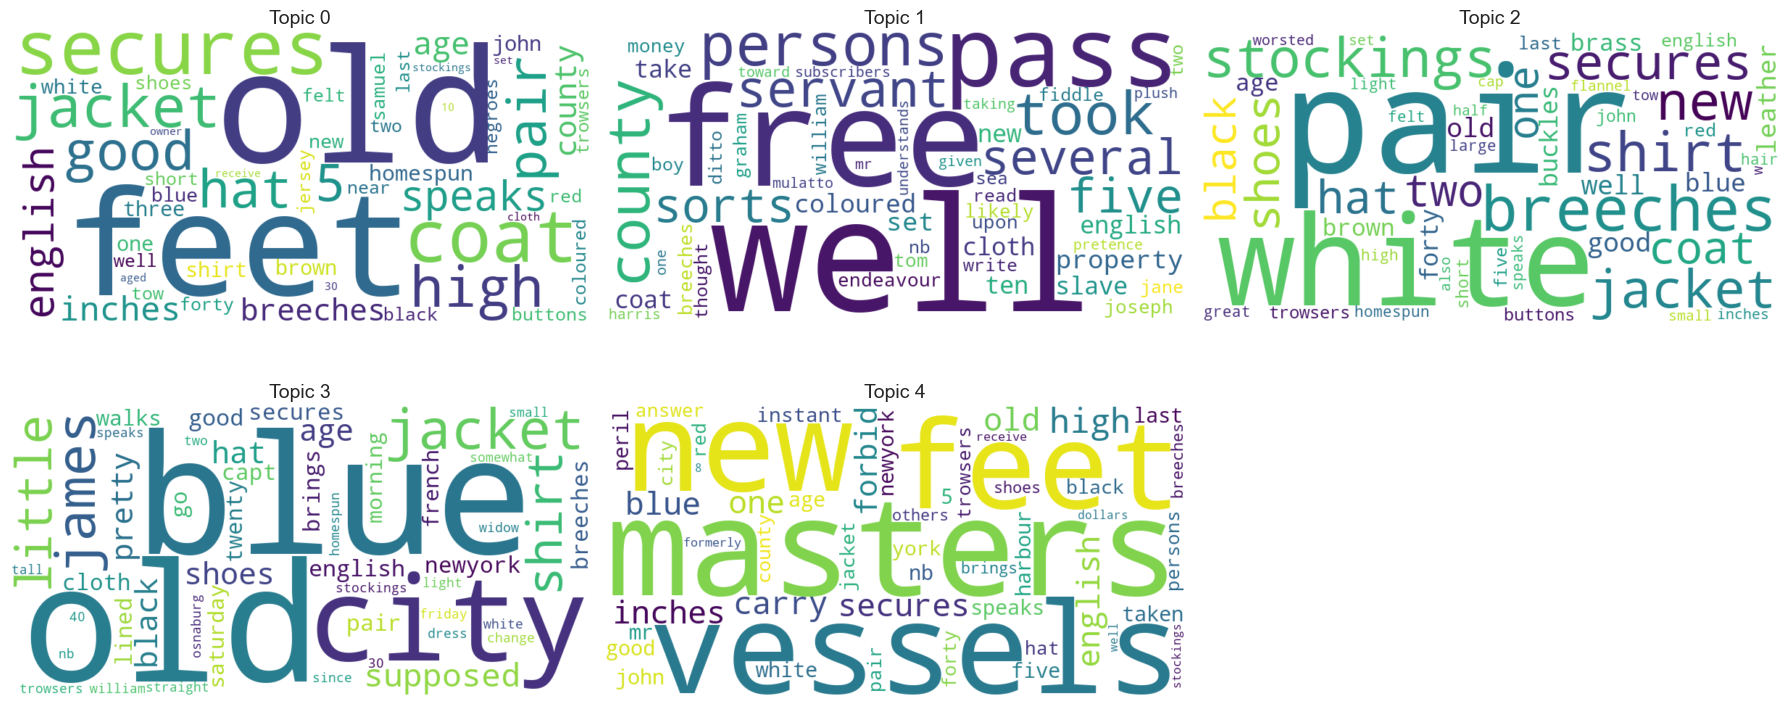

In [17]:
import math
import matplotlib.pyplot as plt

# ensure wordcloud is available
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wordcloud"])
    from wordcloud import WordCloud

# require `lda_model` to exist
if 'lda_model' not in globals():
    raise NameError("`lda_model` not found. Run the LDA training cell first.")

n_topics = getattr(lda_model, 'num_topics', None)
if n_topics is None:
    # fallback: try length of topics
    try:
        n_topics = len(lda_model.print_topics())
    except Exception:
        raise RuntimeError("Cannot determine number of topics from `lda_model`.")

# layout: choose up to 3 columns for readability
ncols = min(3, n_topics)
nrows = math.ceil(n_topics / ncols)

plt.figure(figsize=(6 * ncols, 4 * nrows))
for topic_id in range(n_topics):
    # get top terms and weights for topic
    terms = lda_model.show_topic(topic_id, topn=50)
    freqs = {word: float(weight) for word, weight in terms}

    wc = WordCloud(width=800, height=400, background_color='white',
                   prefer_horizontal=0.9).generate_from_frequencies(freqs)

    ax = plt.subplot(nrows, ncols, topic_id + 1)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"Topic {topic_id}", fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

Topic 0: Physical Characteristics and Identifiers

Topic 2: Clothing and Appearance

Topic 4: Escape Methods and Locations


/var/folders/vv/gfx_q3l53478yh5pl7vm75000000gn/T/ipykernel_2156/127198558.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weight', y='word', data=df_topic, ax=ax, palette='crest')
/var/folders/vv/gfx_q3l53478yh5pl7vm75000000gn/T/ipykernel_2156/127198558.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weight', y='word', data=df_topic, ax=ax, palette='crest')
/var/folders/vv/gfx_q3l53478yh5pl7vm75000000gn/T/ipykernel_2156/127198558.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weight', y='word', data=df_topic, ax=ax, 

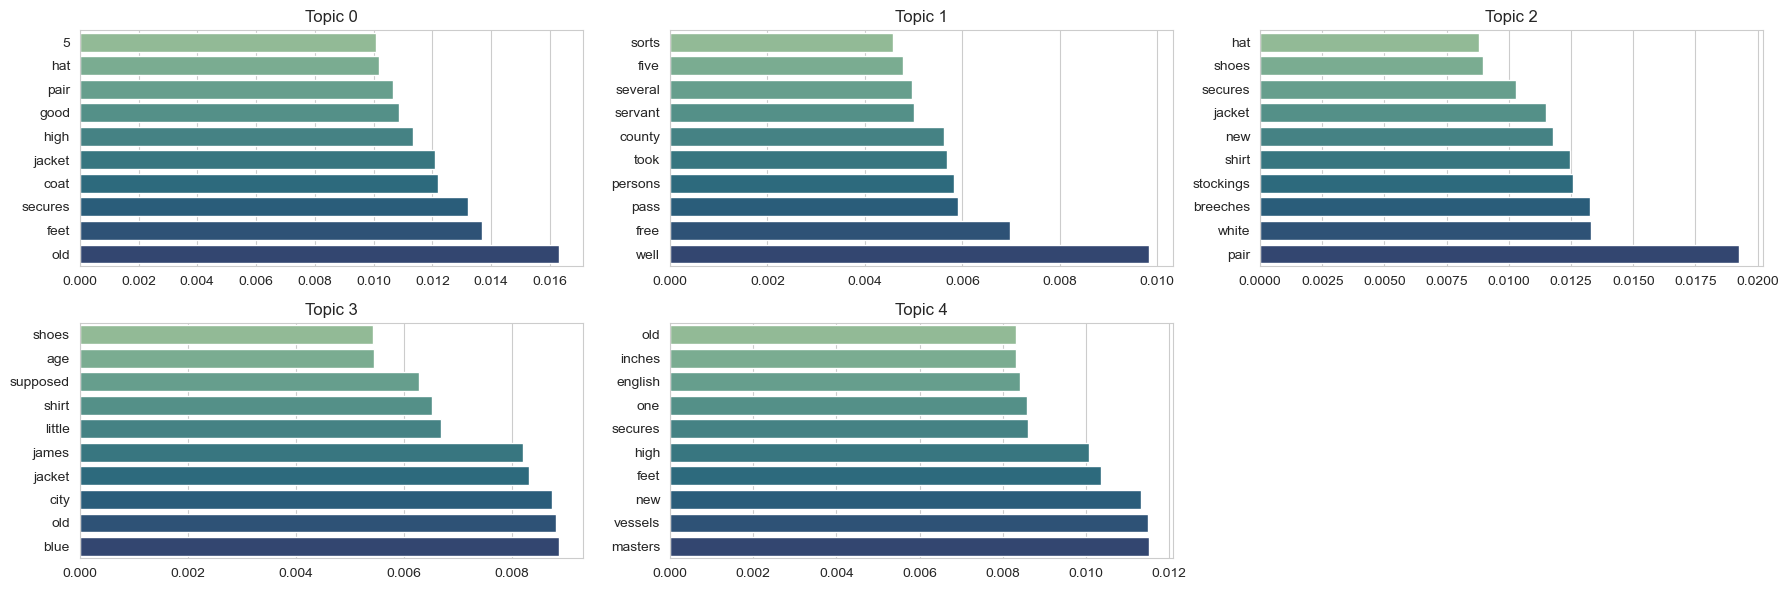

/var/folders/vv/gfx_q3l53478yh5pl7vm75000000gn/T/ipykernel_2156/127198558.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dominant_counts.index.astype(str), y=dominant_counts.values, palette='muted', ax=ax2)


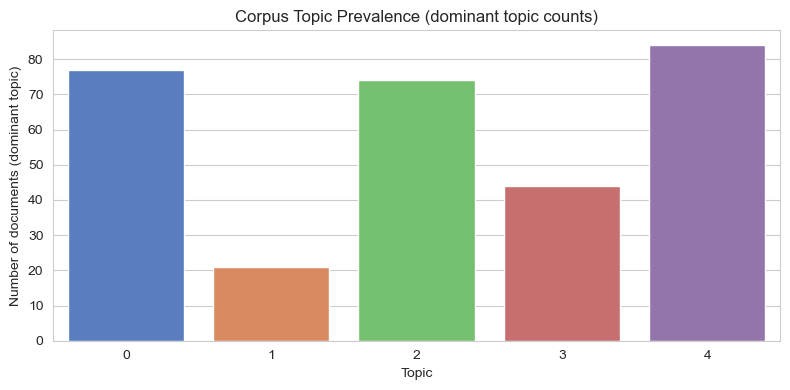

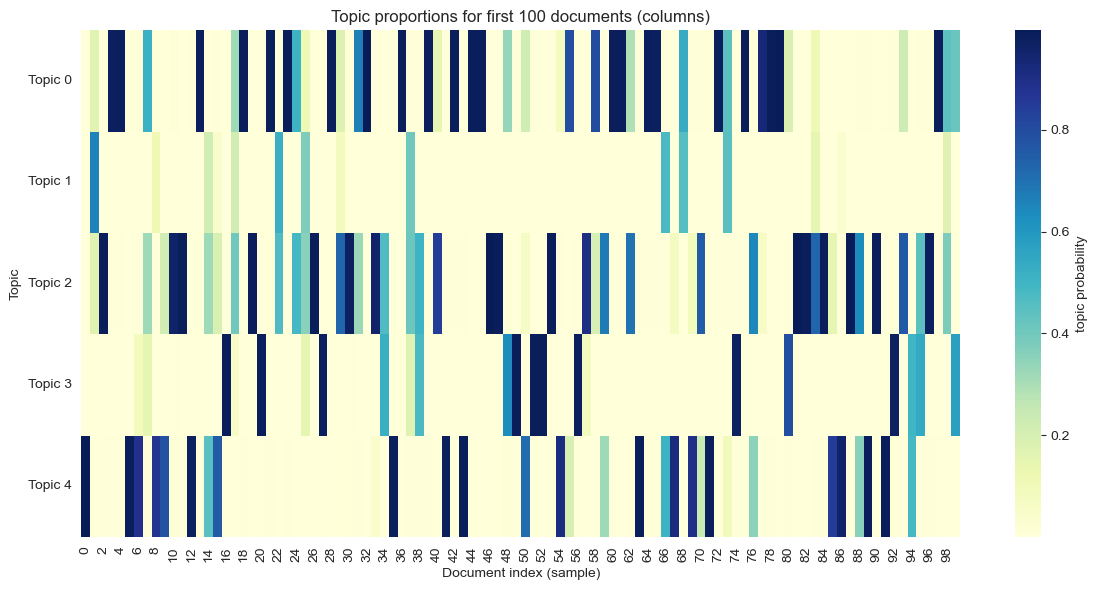

In [18]:
import math
import numpy as np
# Preconditions
if 'lda_model' not in globals():
    raise NameError("`lda_model` not found. Run the LDA training cell first.")
if 'corpus' not in globals():
    raise NameError("`corpus` not found. Recreate corpus from `dictionary` and `df['tokens']`.")
n_topics = getattr(lda_model, 'num_topics', None)
if n_topics is None:
    try:
        n_topics = len(lda_model.print_topics())
    except Exception:
        raise RuntimeError("Cannot determine number of topics from `lda_model`.")

sns.set_style('whitegrid')

# 1) Plot top N words per topic in a grid of horizontal bars
top_n = 10
ncols = min(3, n_topics)
nrows = math.ceil(n_topics / ncols)
fig1, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3 * nrows))
axes = np.array(axes).reshape(-1)  # flatten for easy indexing

for topic_id in range(n_topics):
    ax = axes[topic_id]
    terms = lda_model.show_topic(topic_id, topn=top_n)
    words, weights = zip(*terms)
    # create DataFrame so seaborn handles ordering easily
    df_topic = pd.DataFrame({'word': words, 'weight': weights})
    df_topic = df_topic.sort_values('weight', ascending=True)  # ascending for horizontal bar
    sns.barplot(x='weight', y='word', data=df_topic, ax=ax, palette='crest')
    ax.set_title(f"Topic {topic_id}")
    ax.set_xlabel('')
    ax.set_ylabel('')

# hide any unused subplots
for i in range(n_topics, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 2) Topic prevalence across documents (dominant topic counts)
# Build full topic distribution for each document (ensures all topics shown)
doc_topic_matrix = []
for bow in corpus:
    # get full distribution (minimum_probability=0.0 ensures zeros included)
    topic_probs = dict(lda_model.get_document_topics(bow, minimum_probability=0.0))
    # ensure order by topic id
    doc_topic_matrix.append([topic_probs.get(t, 0.0) for t in range(n_topics)])
doc_topic_matrix = np.array(doc_topic_matrix)

# dominant topic per document
dominant_topics = doc_topic_matrix.argmax(axis=1)
dominant_counts = pd.Series(dominant_topics).value_counts().sort_index()
dominant_counts.index = dominant_counts.index.astype(int)

fig2, ax2 = plt.subplots(figsize=(8, 4))
sns.barplot(x=dominant_counts.index.astype(str), y=dominant_counts.values, palette='muted', ax=ax2)
ax2.set_xlabel('Topic')
ax2.set_ylabel('Number of documents (dominant topic)')
ax2.set_title('Corpus Topic Prevalence (dominant topic counts)')
plt.tight_layout()
plt.show()

# Optional: stacked heatmap of topic proportions for a sample of documents
sample_n = min(100, len(doc_topic_matrix))
fig3, ax3 = plt.subplots(figsize=(12, 6))
sns.heatmap(doc_topic_matrix[:sample_n, :].T, cmap='YlGnBu', cbar_kws={'label': 'topic probability'})
ax3.set_xlabel('Document index (sample)')
ax3.set_ylabel('Topic')
ax3.set_yticks(np.arange(n_topics) + 0.5)
ax3.set_yticklabels([f'Topic {i}' for i in range(n_topics)], rotation=0)
ax3.set_title(f'Topic proportions for first {sample_n} documents (columns)')
plt.tight_layout()
plt.show()

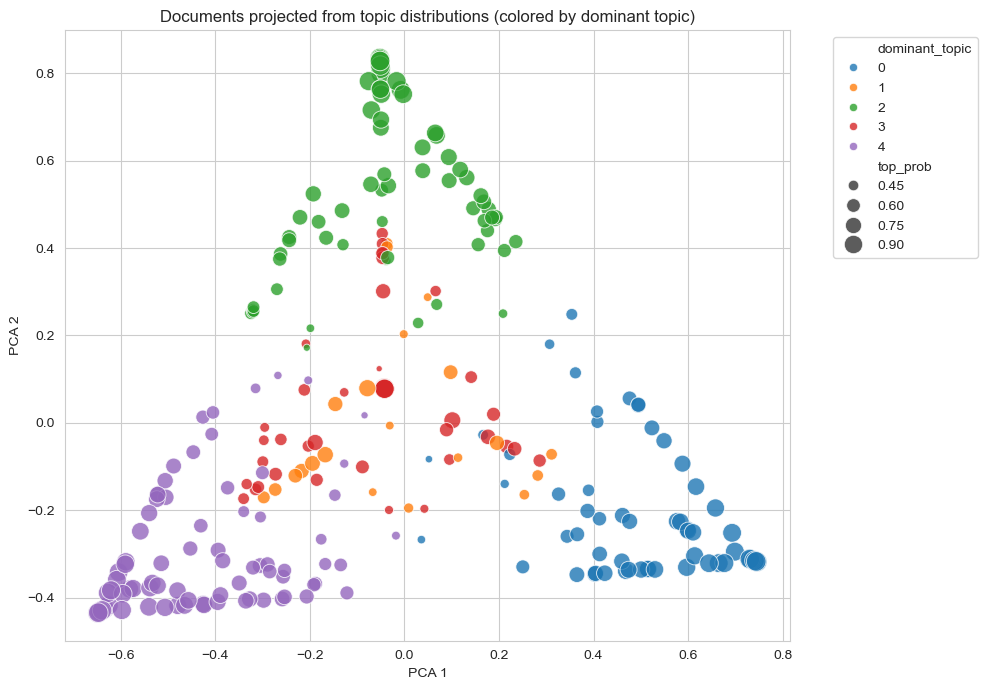

In [19]:
# build doc-topic matrix if not present
if 'doc_topic_matrix' not in globals():
    n_topics = getattr(lda_model, 'num_topics', None)
    if n_topics is None:
        try:
            n_topics = len(lda_model.print_topics())
        except Exception:
            raise RuntimeError("Cannot determine number of topics from `lda_model`.")
    doc_topic_matrix = []
    for bow in corpus:
        probs = dict(lda_model.get_document_topics(bow, minimum_probability=0.0))
        doc_topic_matrix.append([probs.get(t, 0.0) for t in range(n_topics)])
    doc_topic_matrix = np.array(doc_topic_matrix)

# reduce to 2D with PCA (fast, deterministic)
try:
    from sklearn.decomposition import PCA
except Exception as e:
    raise ImportError("sklearn is required for dimensionality reduction. Install scikit-learn.") from e

pca = PCA(n_components=2, random_state=0)
xy = pca.fit_transform(doc_topic_matrix)

# prepare plotting DataFrame
dominant = doc_topic_matrix.argmax(axis=1)
top_prob = doc_topic_matrix.max(axis=1)
plot_df = pd.DataFrame({
    'x': xy[:, 0],
    'y': xy[:, 1],
    'dominant_topic': dominant.astype(int),
    'top_prob': top_prob
})

sns.set_style('whitegrid')
plt.figure(figsize=(10, 7))
palette = sns.color_palette('tab10', n_colors=max(2, int(plot_df['dominant_topic'].max() + 1)))
ax = sns.scatterplot(
    data=plot_df,
    x='x', y='y',
    hue='dominant_topic',
    size='top_prob',
    sizes=(20, 200),
    palette=palette,
    alpha=0.8,
    legend='brief'
)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_title('Documents projected from topic distributions (colored by dominant topic)')
# improve legend: show topic labels only
handles, labels = ax.get_legend_handles_labels()
# the legend contains both size and hue entries; keep up to n_topics hue entries plus size
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Now we identified the topics and their frequency, we can deep dive into specific topics. For example, topic 4 on escape methods which were the most frequent topic (see histogram of corpus topic prevalence).

## Descriptive Analysis For Escape Methods and Locations
From the topic modeling, we can identify specific words related to escape methods and locations. We can further analyze the frequency of these words in the corpus to understand common strategies and places associated with runaway slaves by applying similar methodology with n-grams and temporal analysis we conducted with the whole dataset

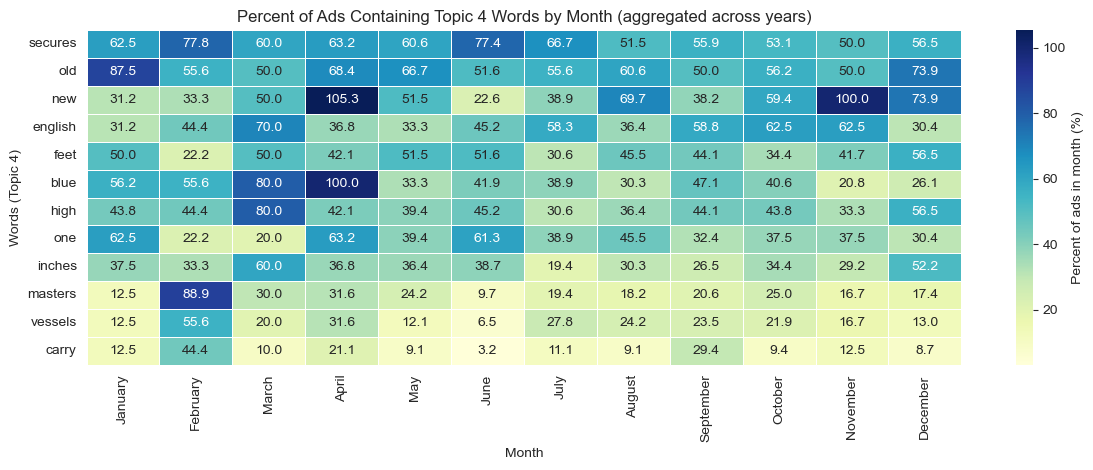

In [20]:
# parameters
topic_id = 4
top_n_words = 12

# validate topic id
n_topics = getattr(lda_model, 'num_topics', None)
if n_topics is None:
    try:
        n_topics = len(lda_model.print_topics())
    except Exception:
        raise RuntimeError("Cannot determine number of topics from `lda_model`.")
if topic_id >= n_topics:
    raise ValueError(f"Requested topic_id {topic_id} >= number of topics {n_topics}.")

# get top words for the topic
terms = lda_model.show_topic(topic_id, topn=top_n_words)
words = [str(w).lower() for w, _ in terms]

# month helpers
months = list(range(1, 13))
month_names = [calendar.month_name[m] for m in months]

# total ads per month (aggregated across years)
month_totals = (
    df.dropna(subset=['Month'])
      .astype({'Month': int})
      .groupby('Month')
      .size()
      .reindex(months, fill_value=0)
)
month_totals_values = month_totals.values  # aligns with month_names order

# build raw counts per word x month
counts = pd.DataFrame(0, index=words, columns=month_names)

for m in months:
    month_name = calendar.month_name[m]
    subset = df.loc[df['Month'] == m, 'tokens'].dropna()
    for tokens in subset:
        if not isinstance(tokens, (list, tuple)):
            continue
        lowered = [str(t).lower() for t in tokens]
        doc_counts = pd.Series(lowered).value_counts()
        for w in words:
            counts.at[w, month_name] += int(doc_counts.get(w, 0))

# sort words by total absolute frequency for nicer display
counts['total'] = counts.sum(axis=1)
counts = counts.sort_values('total', ascending=False)
counts = counts.drop(columns='total')

# convert to percent of ads in that month (avoid division by zero)
# month_totals_values is length 12 and corresponds to month_names order
# division yields NaN for months with zero total; replace with 0
counts_percent = counts.div(month_totals_values, axis=1).fillna(0) * 100.0

# plot heatmap (percent of ads containing the word in that month)
sns.set_style('whitegrid')
plt.figure(figsize=(12, max(4, 0.4 * len(words))))
ax = sns.heatmap(
    counts_percent,
    cmap='YlGnBu',
    annot=True,
    fmt='.1f',
    linewidths=.5,
    cbar_kws={'label': 'Percent of ads in month (%)'}
)
ax.set_xlabel('Month')
ax.set_ylabel(f'Words (Topic {topic_id})')
ax.set_title(f'Percent of Ads Containing Topic {topic_id} Words by Month (aggregated across years)')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Why master's vessel is so frequent in February?

We can do a similar analysis to topic 2 words about clothing and appearance.

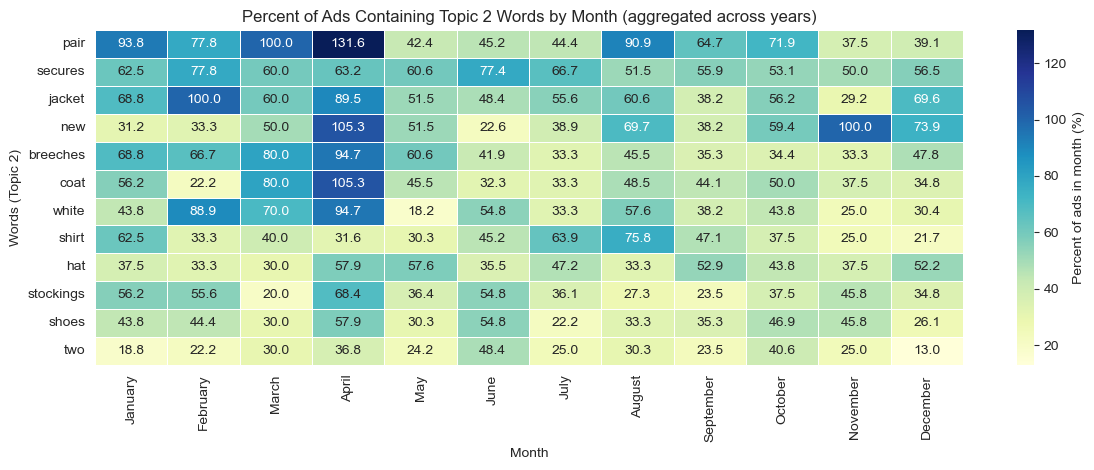

In [21]:
# parameters
topic_id = 2
top_n_words = 12

# validate topic id
n_topics = getattr(lda_model, 'num_topics', None)
if n_topics is None:
    try:
        n_topics = len(lda_model.print_topics())
    except Exception:
        raise RuntimeError("Cannot determine number of topics from `lda_model`.")
if topic_id >= n_topics:
    raise ValueError(f"Requested topic_id {topic_id} >= number of topics {n_topics}.")

# get top words for the topic
terms = lda_model.show_topic(topic_id, topn=top_n_words)
words = [str(w).lower() for w, _ in terms]

# month helpers
months = list(range(1, 13))
month_names = [calendar.month_name[m] for m in months]

# total ads per month (aggregated across years)
month_totals = (
    df.dropna(subset=['Month'])
      .astype({'Month': int})
      .groupby('Month')
      .size()
      .reindex(months, fill_value=0)
)
month_totals_values = month_totals.values  # aligns with month_names order

# build raw counts per word x month
counts = pd.DataFrame(0, index=words, columns=month_names)

for m in months:
    month_name = calendar.month_name[m]
    subset = df.loc[df['Month'] == m, 'tokens'].dropna()
    for tokens in subset:
        if not isinstance(tokens, (list, tuple)):
            continue
        lowered = [str(t).lower() for t in tokens]
        doc_counts = pd.Series(lowered).value_counts()
        for w in words:
            counts.at[w, month_name] += int(doc_counts.get(w, 0))

# sort words by total absolute frequency for nicer display
counts['total'] = counts.sum(axis=1)
counts = counts.sort_values('total', ascending=False)
counts = counts.drop(columns='total')

# convert to percent of ads in that month (avoid division by zero)
# month_totals_values is length 12 and corresponds to month_names order
# division yields NaN for months with zero total; replace with 0
counts_percent = counts.div(month_totals_values, axis=1).fillna(0) * 100.0

# plot heatmap (percent of ads containing the word in that month)
sns.set_style('whitegrid')
plt.figure(figsize=(12, max(4, 0.4 * len(words))))
ax = sns.heatmap(
    counts_percent,
    cmap='YlGnBu',
    annot=True,
    fmt='.1f',
    linewidths=.5,
    cbar_kws={'label': 'Percent of ads in month (%)'}
)
ax.set_xlabel('Month')
ax.set_ylabel(f'Words (Topic {topic_id})')
ax.set_title(f'Percent of Ads Containing Topic {topic_id} Words by Month (aggregated across years)')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

And for topic 0 on physical characteristics

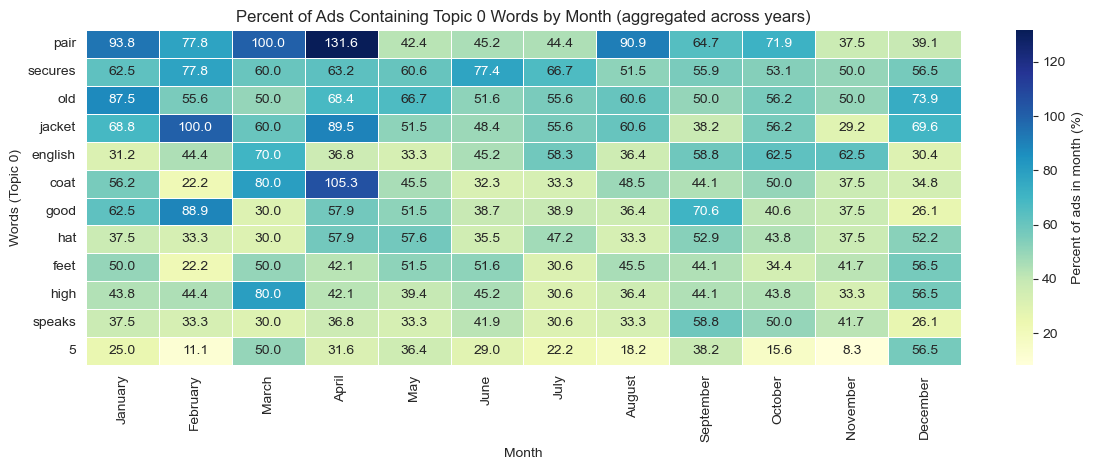

In [23]:
# parameters
topic_id = 0
top_n_words = 12

# validate topic id
n_topics = getattr(lda_model, 'num_topics', None)
if n_topics is None:
    try:
        n_topics = len(lda_model.print_topics())
    except Exception:
        raise RuntimeError("Cannot determine number of topics from `lda_model`.")
if topic_id >= n_topics:
    raise ValueError(f"Requested topic_id {topic_id} >= number of topics {n_topics}.")

# get top words for the topic
terms = lda_model.show_topic(topic_id, topn=top_n_words)
words = [str(w).lower() for w, _ in terms]

# month helpers
months = list(range(1, 13))
month_names = [calendar.month_name[m] for m in months]

# total ads per month (aggregated across years)
month_totals = (
    df.dropna(subset=['Month'])
      .astype({'Month': int})
      .groupby('Month')
      .size()
      .reindex(months, fill_value=0)
)
month_totals_values = month_totals.values  # aligns with month_names order

# build raw counts per word x month
counts = pd.DataFrame(0, index=words, columns=month_names)

for m in months:
    month_name = calendar.month_name[m]
    subset = df.loc[df['Month'] == m, 'tokens'].dropna()
    for tokens in subset:
        if not isinstance(tokens, (list, tuple)):
            continue
        lowered = [str(t).lower() for t in tokens]
        doc_counts = pd.Series(lowered).value_counts()
        for w in words:
            counts.at[w, month_name] += int(doc_counts.get(w, 0))

# sort words by total absolute frequency for nicer display
counts['total'] = counts.sum(axis=1)
counts = counts.sort_values('total', ascending=False)
counts = counts.drop(columns='total')

# convert to percent of ads in that month (avoid division by zero)
# month_totals_values is length 12 and corresponds to month_names order
# division yields NaN for months with zero total; replace with 0
counts_percent = counts.div(month_totals_values, axis=1).fillna(0) * 100.0

# plot heatmap (percent of ads containing the word in that month)
sns.set_style('whitegrid')
plt.figure(figsize=(12, max(4, 0.4 * len(words))))
ax = sns.heatmap(
    counts_percent,
    cmap='YlGnBu',
    annot=True,
    fmt='.1f',
    linewidths=.5,
    cbar_kws={'label': 'Percent of ads in month (%)'}
)
ax.set_xlabel('Month')
ax.set_ylabel(f'Words (Topic {topic_id})')
ax.set_title(f'Percent of Ads Containing Topic {topic_id} Words by Month (aggregated across years)')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Future Research Directions
If we want to gain counter-history narratives, we need to go beyond the classical frequency explorations I did in this notebook. The intersection of "Big Data" and historical inquiry presents a methodological paradox. While computational analysis offers the ability to process vast archives, it risks reinforcing the biases inherent in the data itself. If the archive is a product of power—constructed by the colonizer to catalog the colonized—does a purely quantitative approach merely amplify the "master's voice"? This paper argues that standard computational analysis, which often prioritizes the most frequent or prominent patterns, risks obscuring the subtle acts of resistance that define the lives of marginalized communities. To recover the "hidden voices" of the enslaved from the 18th-century mid-Atlantic, we must move beyond simple frequency counts and employ a "creative" distant reading that reads against the grain of the dataset.